# Lesson 09 · RAG avançado · Resultados para os slides

Sem live code nesta aula. Este notebook roda **antes** da aula e as saídas vão coladas nos slides "What the notebook shows" (RESULT 1 a 4) e no placar. Quatro células de resultado, uma por família de técnica. Cada uma troca **uma** função de contrato do RAG clássico da aula 8 e roda as mesmas 20 perguntas, no mesmo corpus, com o mesmo harness. A última célula empilha tudo contra a linha de base e grava o gráfico do slide final.

| RESULT | Família | Técnica | O que troca | Problema do slide "Where vanilla RAG breaks" |
|---|---|---|---|---|
| 1 | F1 · Before searching | HyDE | `retrieve` na entrada | Question / doc mismatch |
| 2 | F2 · How to search | Híbrido BM25 + denso, fusão por RRF | `build_index` + `retrieve` | One retriever |
| 3 | F3 · After searching | Reranking com cross-encoder | `retrieve` na saída | Lost in the middle |
| 4 | F4 · The control loop | Corrective RAG | `retrieve` num laço + `build_prompt` | Blind trust |

O núcleo (células "Núcleo") é **idêntico** ao do `lesson09_exercise.ipynb`; a demo só chama as funções. Roda na máquina do professor com o Ollama local (`ollama serve`, modelos `qwen2.5:3b` e `nomic-embed-text`) ou no Google Colab com o bloco de preparação abaixo.

Rode tudo de cima a baixo uma vez (uns 10 minutos no Colab T4). Cada célula de resultado grava `results_<variante>.csv`; se rodar de novo, `cached(...)` reaproveita o CSV, e `cached(..., force=True)` força a rodada. Para os slides, copie a saída de texto de cada célula RESULT (ou um print) e o `lesson09_scoreboard.png`.

---
## 🧰 Preparação no Colab (pule se estiver na sua máquina com o Ollama instalado)

Três células, uns 4 minutos. Escolha o runtime **T4 GPU**.

In [21]:
# Colab 1 · Instala o Ollama e sobe o servidor em segundo plano.
!apt-get install -y -qq zstd > /dev/null 2>&1 || (apt-get update -qq > /dev/null 2>&1 && apt-get install -y -qq zstd > /dev/null 2>&1)
!curl -fsSL https://ollama.com/install.sh | sh 2>&1 | tail -n 2
import subprocess, time, requests
OLLAMA_URL = "http://localhost:11434"
def server_is_up():
    try: return requests.get(f"{OLLAMA_URL}/api/version", timeout=2).ok
    except requests.RequestException: return False
if not server_is_up():
    subprocess.Popen(["ollama", "serve"], stdout=open("ollama.log", "w"), stderr=subprocess.STDOUT, start_new_session=True)
    for _ in range(30):
        if server_is_up(): break
        time.sleep(1)
print("servidor no ar:", server_is_up())

>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
servidor no ar: True
⏱ 60.6 s


In [22]:
# Colab 2 · Baixa os dois modelos da demo (os mesmos da aula 8). O 3B faz três papéis novos: escritor (HyDE), avaliador e reescritor (CRAG).
!ollama pull qwen2.5:3b
!ollama pull nomic-embed-text
!ollama list



NAME                       ID              SIZE      MODIFIED               
qwen2.5:3b                 357c53fb659c    1.9 GB    Less than a second ago    
nomic-embed-text:latest    0a109f422b47    274 MB    Less than a second ago    
⏱ 1.2 s


In [23]:
# Colab 3 · Pacotes Python. Um novo em relação à aula 8: sentence-transformers, que traz o cross-encoder do LIVE 3.
!pip -q install openai chromadb requests pandas matplotlib sentence-transformers

⏱ 4.0 s


---
## Núcleo · aula 8 (sem alterações), cronômetro, corpus e perguntas

In [24]:
# Núcleo do RAG clássico da aula 8, copiado sem alterações (só o diretório do Chroma mudou). Nada aqui é novo.
import os, re, glob, json, time, requests
from openai import OpenAI
import chromadb

OLLAMA_URL = "http://localhost:11434"
GEN_MODEL  = "qwen2.5:3b"            # o gerador (o Léo). Troque por "qwen2.5:0.5b" se a máquina sofrer.
EMB_MODEL  = "nomic-embed-text"      # o modelo de embedding. Tem de ser O MESMO na indexação e na consulta.
CORPUS_DIR = "corpus"
CHROMA_DIR = "chroma_lesson09"

client = OpenAI(base_url=f"{OLLAMA_URL}/v1", api_key="ollama")

# ---- tokens. Aqui 1 token = 1 palavra (com o espaço que a precede), para o notebook não depender de nada.
# Tokenizadores reais (BPE) produzem cerca de 30% mais tokens que palavras. A proporção entre os tamanhos é o que importa.
def tokenize(text):   return re.findall(r"\s*\S+", text)
def detokenize(toks): return "".join(toks).strip()
def count_tokens(text): return len(tokenize(text))

# ---- Load
def load_corpus(folder=CORPUS_DIR):
    docs = []
    for path in sorted(glob.glob(os.path.join(folder, "*.md"))):
        docs.append({"doc": os.path.basename(path), "text": open(path, encoding="utf-8").read()})
    return docs

# ---- Chunk (tamanho fixo com overlap, em tokens)
def chunk_fixed(text, chunk_size=512, overlap=51):
    toks, step, out = tokenize(text), chunk_size - overlap, []
    for start in range(0, max(len(toks), 1), step):
        out.append(detokenize(toks[start:start + chunk_size]))
        if start + chunk_size >= len(toks):
            break
    return out

def make_chunks(docs, chunk_size=512, overlap=51):
    """Uma linha por chunk: id, texto e metadados (documento, posição, última seção vista)."""
    rows = []
    for d in docs:
        carried = "-"                                          # última seção vista no chunk anterior
        for i, c in enumerate(chunk_fixed(d["text"], chunk_size, overlap)):
            heads = [(m.start(), m.group(1)[:80]) for m in re.finditer(r"^#+ (.+)$", c, re.M)]
            first_half = [h for pos, h in heads if pos < len(c) / 2]
            section = first_half[-1] if first_half else carried   # a seção que domina o chunk
            if heads:
                carried = heads[-1][1]
            rows.append({"id": f"{d['doc']}#{i}", "text": c,
                         "doc": d["doc"], "chunk": i, "section": section})
    return rows

GROUNDING = ("You are the pit-wall assistant of Aurora Racing. Answer using ONLY the context below. "
             "If the context does not contain the answer, say exactly: \"The handbook does not cover this.\" "
             "Every fact you state must carry its source in square brackets, copied from the context labels, "
             "like [handbook_tyres.md · 2.2 Reference pressures]. "
             "End your answer with one line in exactly this format:\n"
             "Sources: [file · section], [file · section]")

def sources_used(hits):
    """A lista de fontes vem da recuperação, não do modelo. É o que se mostra ao usuário."""
    seen, out = set(), []
    for h in hits:
        key = f"{h['doc']} · {h['section']}"
        if key not in seen:
            seen.add(key); out.append(key)
    return out

# ---- Embed (Ollama /api/embed devolve uma lista de vetores)
def embed(texts, model=EMB_MODEL):
    r = requests.post(f"{OLLAMA_URL}/api/embed", json={"model": model, "input": texts})
    r.raise_for_status()
    return r.json()["embeddings"]

# ---- Store (Chroma persistente, distância = 1 - cosseno)
def build_index(rows, name, persist_dir=CHROMA_DIR, batch=32, rebuild=False):
    store = chromadb.PersistentClient(path=persist_dir)
    if rebuild:
        try: store.delete_collection(name)
        except Exception: pass
    col = store.get_or_create_collection(name, metadata={"hnsw:space": "cosine", "embedding_model": EMB_MODEL})
    if col.count() == len(rows):
        return col                                   # já indexado; não paga o embedding de novo
    for i in range(0, len(rows), batch):
        part = rows[i:i + batch]
        col.upsert(ids=[r["id"] for r in part], documents=[r["text"] for r in part],
                   embeddings=embed([r["text"] for r in part]),
                   metadatas=[{"doc": r["doc"], "chunk": r["chunk"], "section": r["section"]} for r in part])
    return col

# ---- Retrieve
def retrieve(col, question, k=4):
    assert col.metadata.get("embedding_model") == EMB_MODEL, "índice e consulta com modelos de embedding diferentes"
    res = col.query(query_embeddings=embed([question]), n_results=k, include=["documents", "metadatas", "distances"])
    return [{"text": t, "doc": m["doc"], "section": m["section"], "distance": d}
            for t, m, d in zip(res["documents"][0], res["metadatas"][0], res["distances"][0])]

# ---- Augment
GROUNDING = ("You are the pit-wall assistant of Aurora Racing. Answer using ONLY the context below. "
             "If the context does not contain the answer, say exactly: \"The handbook does not cover this.\" "
             "Cite the source of each fact in square brackets, like [handbook_tyres.md].")
FREE = "You are the pit-wall assistant of Aurora Racing. Answer the question."

def build_prompt(question, hits, grounded=True):
    context = "\n\n".join(f"[{h['doc']} · {h['section']}]\n{h['text']}" for h in hits)
    system = GROUNDING if grounded else FREE
    user = f"Context:\n{context}\n\nQuestion: {question}" if hits else f"Question: {question}"
    return [{"role": "system", "content": system}, {"role": "user", "content": user}]

# ---- Generate
def generate(messages, model=GEN_MODEL, temperature=0.0, max_tokens=300):
    t0 = time.time()
    resp = client.chat.completions.create(model=model, messages=messages, temperature=temperature, max_tokens=max_tokens)
    return resp.choices[0].message.content.strip(), time.time() - t0

def warm_up():
    """Carrega os dois modelos na memória e pede ao Ollama para mantê-los lá (keep_alive=-1). Evita pagar a carga na primeira pergunta."""
    requests.post(f"{OLLAMA_URL}/api/embed", json={"model": EMB_MODEL, "input": "warm up", "keep_alive": -1}).raise_for_status()
    requests.post(f"{OLLAMA_URL}/api/generate", json={"model": GEN_MODEL, "prompt": "hi", "keep_alive": -1, "stream": False,
                                                       "options": {"num_predict": 1}}).raise_for_status()
    for m in requests.get(f"{OLLAMA_URL}/api/ps").json().get("models", []):
        where = "GPU" if m.get("size_vram", 0) >= m.get("size", 1) * 0.9 else ("parcial GPU" if m.get("size_vram", 0) else "CPU")
        print(f"{m['name']:<24} carregado em {where}")

def show(hits):
    for i, h in enumerate(hits, 1):
        print(f"[{i}] {h['doc']} · {h['section']}  (distance {h['distance']:.3f})")
        print("    " + h["text"][:160].replace("\n", " ") + " ...")

⏱ 0.0 s


In [25]:
# Cronômetro automático. A partir daqui toda célula imprime o seu tempo de execução (⏱) e o registra em CELL_TIMES.
import time
from IPython import get_ipython

CELL_TIMES = []
_ip = get_ipython()

def _pre_run(info):
    _ip._t0 = time.perf_counter()

def _post_run(result):
    dt = time.perf_counter() - getattr(_ip, "_t0", time.perf_counter())
    first_line = (result.info.raw_cell.strip().splitlines() or [""])[0][:70]
    CELL_TIMES.append({"cell": first_line, "seconds": round(dt, 2)})
    print(f"⏱ {dt:.1f} s")

if not getattr(_ip, "_timer_installed", False):          # evita registrar duas vezes se a célula for rerodada
    _ip._t0 = time.perf_counter()
    _ip.events.register("pre_run_cell", _pre_run)
    _ip.events.register("post_run_cell", _post_run)
    _ip._timer_installed = True
print("cronômetro ligado")

cronômetro ligado
⏱ 0.0 s


In [26]:
# O corpus da aula 8 e as 20 perguntas (questions.json) vivem dentro do notebook, para não depender de download.
import os, json
os.makedirs(CORPUS_DIR, exist_ok=True)
CORPUS = {
    "car_specs.md": "# Aurora Racing · Team Handbook · Section 3 · Car specification (AR-26)\n\nThe AR-26 is the team's 2026 car. Both cars 27 and 88 share the same specification except for the setup items listed in Section 1.\n\n- Power unit: Aurora PU-26, 1.6 litre V6 turbo hybrid, supplied by the team's own engine division.\n- Minimum weight: 798 kg including the driver.\n- Wheelbase: 3,600 mm.\n- Gearbox: eight forward gears plus reverse, seamless shift.\n- Brakes: carbon discs, 328 mm front and 280 mm rear.\n- Fuel tank capacity: 110 kg.\n- Steering wheel: 22 buttons and 6 rotaries, including the fuel rotary and the overtake button.\n- Data: about 300 sensors, streaming roughly 1.5 GB per race weekend per car to the pit wall and to the factory in Silverstone.\n",
    "comms_protocol.md": "# Aurora Racing · Team Handbook · Section 8 · Communications protocol\n\n## 8.1 Who talks to the driver\n\nDuring a stint only the race engineer speaks to the driver on the driver channel. The strategist, the chief mechanic and the team principal speak to the race engineer on the intercom, and the race engineer decides what to pass on. The only exception is a safety call, which anyone on the pit wall may make directly.\n\n## 8.2 Channels\n\nThere are three radio channels. The driver channel connects the driver and the race engineer. The crew channel connects the pit-stop crew and the chief mechanic; the \"check\" calls of the wet pit stop are made here. The intercom connects everyone on the pit wall and the factory support room.\n\n## 8.3 Timing\n\nMessages to the driver are sent on the straights, never in a braking zone. Long messages are split. The race engineer waits for \"copy\" before sending another instruction.\n",
    "drivers.md": "# Aurora Racing · Team Handbook · Section 1 · Drivers\n\n## Car 27 · Luca Ferrand\n\nLuca Ferrand drives car 27. He was born in Lyon, France, in 1998 and joined Aurora Racing in 2022 after two seasons in Formula 2, where he finished third in the 2021 championship. His race engineer is Priya Nandakumar. Ferrand prefers a front-limited car and tends to ask for more front wing during a stint. His radio style is short; he rarely speaks unless asked.\n\n## Car 88 · Mika Sørensen\n\nMika Sørensen drives car 88. She was born in Aarhus, Denmark, in 2001 and joined the team in 2024 from the Aurora junior programme. Her race engineer is Tomás Reyes. Sørensen runs a stiffer rear anti-roll bar than Ferrand, which is why car 88 uses a slightly higher rear tyre pressure in the wet. She talks more on the radio and gives detailed feedback about tyre behaviour, which the strategists value.\n\n## Reserve driver\n\nThe reserve driver is Kenji Watanabe, who also runs the simulator programme on Friday evenings. He has no race starts with the team.\n",
    "fuel_and_energy.md": "# Aurora Racing · Team Handbook · Section 5 · Fuel and energy\n\n## 5.1 Fuel load\n\nThe race fuel load is the calculated consumption for the race distance plus a safety margin. The standard margin is 0.8 kg. The margin is set on Saturday evening by the performance engineer and cannot be changed after the car leaves the garage for the formation lap.\n\n## 5.2 Fuel rule under safety car\n\nWhen the safety car is deployed, consumption drops but the race can be extended by a restart at full pace. The rule is that under safety car the driver switches to fuel mode 3 and the target margin is raised to 1.5 kg. The race engineer confirms the new margin on the radio with the phrase \"margin one five\". If the margin cannot be recovered before the restart, the driver is asked to lift and coast for the rest of the race.\n\n## 5.3 Energy deployment\n\nThe energy store may deploy up to 4 MJ per lap. The default deployment map keeps 0.5 MJ in reserve for the overtake button. In \"mode push\" the reserve is released and the full 4 MJ is available for one lap, after which the map returns to default automatically.\n",
    "garage_and_pitlane.md": "# Aurora Racing · Team Handbook · Section 10 · Garage and pit lane\n\nThe garage has two bays, car 27 on the left and car 88 on the right when seen from the pit lane. The tyre area is at the back of the garage and the blankets are powered from the left wall.\n\nThe pit lane speed limit is 80 km/h at most circuits and 60 km/h at circuits with a short pit lane such as Monaco and Singapore. The speed limiter is engaged by the driver at the pit entry line. Exceeding the limit is a penalty for the team.\n\nThe pit box is marked with two lines. The front jack operator stands on the front line and the car must stop with the front wing over it. If the car overshoots, the crew pulls it back before starting the stop.\n",
    "handbook_procedures.md": "# Aurora Racing · Team Handbook · Section 4 · Pit-stop procedures\n\nThis section describes the standard pit-stop procedures for cars 27 and 88. Every procedure has a code in the procedure register (Section 9) so that it can be named on the radio without ambiguity. The chief mechanic owns this section, reviews it after every race weekend and publishes changes on the Monday briefing. Crew members are expected to know the procedure in force before the car leaves the garage for the first time in a session. Practice stops are run on Thursday afternoon and on Saturday morning, and the stationary times are logged in the pit-stop sheet together with the names of the crew on each corner.\n\n## 4.1 Dry-race pit stop (code P-D1)\n\nThe dry pit stop is the default procedure and the one the crew practises most. The crew is 18 people: four wheel-gun operators (one per corner), eight tyre carriers (two per corner, one to remove the used tyre and one to fit the new one), two jack operators (front and rear), two stabilisers who hold the car steady at the sidepods, one front-wing adjuster and one lollipop controller who gives the release signal from the front of the car.\n\nTarget stationary time is 2.4 seconds. The record for the team is 2.1 seconds, set in 2025. Dry tyre pressures at the stop are 22.0 psi front and 20.0 psi rear for car 27, and 22.5 psi front and 20.0 psi rear for car 88. Pressures are set in the garage before the tyres go to the pit wall and are not checked again during the stop; the gauge stays in the garage. The car is released as soon as the four wheel guns confirm with the green light on the gantry and both jacks drop. The front-wing adjuster works only when the race engineer has called an adjustment before the car enters the pit lane, and the adjustment is expressed in turns of the flap screw, for example \"front wing plus two\".\n\nIf a wheel gun fails to confirm, the lollipop controller holds the car and the corner is redone. A stop with a redo is reported to the chief mechanic immediately after the race, together with the video from the garage camera.\n\nCrew positions are fixed for the season and printed on the pit-stop sheet. A crew member who is unavailable for a race is replaced by the named reserve for that corner, and the reserve runs at least ten practice stops on Thursday before being allowed on the live stop. The chief mechanic may swap corners between the two cars only on Saturday morning, never on race day. Every practice and live stop is filmed from the gantry camera, and the video is reviewed on Monday with the stationary times, the release time and the time lost in the pit lane.\n\n## 4.2 Wet-race pit stop (code P27-W1 for car 27, code P88-W1 for car 88)\n\nThe wet pit stop adds a pressure check to the dry procedure because the intermediate and full wet tyres are more sensitive to pressure and because the blankets run cooler for those compounds. For car 27 in wet conditions the front tyres are set to 23.5 psi and the rear tyres to 21.0 psi. For car 88 the front tyres are set to 23.5 psi and the rear tyres to 21.5 psi, because car 88 runs a stiffer rear anti-roll bar and needs a little more support from the tyre.\n\nBefore the car is released, one of the tyre carriers on each side reads the pressure on the gauge and calls \"check\" on the crew channel. The lollipop controller may only release the car after hearing four \"check\" calls, one per corner. This adds about 0.8 seconds to the stationary time and is accepted; a wet stop with a stationary time of 3.2 seconds is considered good. There is no warm-up sequence in the wet procedure; the tyres come from the blankets directly to the car and the blankets for intermediates and wets are set to 40 degrees Celsius as described in Section 2.\n\nVisibility in the pit box is worse in the wet, so the stabilisers wear the high-visibility vests and the lollipop controller uses the lit paddle instead of the standard board. Wheel-gun operators kneel on the anti-slip mats, which are laid out as soon as rain is forecast for the session.\n\n## 4.3 Pit stop under safety car (code P-SC)\n\nUnder the safety car the pit lane is usually crowded, because most of the field stops at the same time to take advantage of the reduced time loss. The crew leaves the garage only after the strategist confirms the gap to the car behind and the expected position at the pit exit. The procedure is otherwise identical to the dry or wet procedure in force at the time: pressures, crew positions and release rules do not change.\n\nTwo details are specific to the safety-car stop. The front-wing adjuster does not touch the wing unless the race engineer calls the adjustment explicitly, because the time gained by the adjustment rarely justifies the risk of an unsafe release in a crowded lane. And the lollipop controller checks the pit lane for approaching cars before releasing, in addition to the wheel-gun lights, since an unsafe release under safety car is the most common penalty in this scenario.\n\n## 4.4 Red flag (code P-RF)\n\nUnder a red flag both cars return to the garage and the session is suspended. Tyres may be changed in the garage without the pit-stop crew, using the garage jacks and the standard wheel guns. The pressure values in force are the same as in 4.1 or 4.2 depending on the conditions declared by race control. The chief mechanic decides whether the car goes back to the grid on the same set or on a new set, after consulting the strategist about the remaining race distance and the tyre allocation.\n\nDuring the suspension the crew may also repair minor damage, replace the front wing and adjust the fuel load only if race control allows it; the race engineer confirms what is allowed on the intercom before any work starts. The car leaves the garage for the restart only when the chief mechanic gives the go on the crew channel.\n",
    "handbook_tyres.md": "# Aurora Racing · Team Handbook · Section 2 · Tyres\n\n## 2.1 Compounds\n\nFive dry compounds are available to the team during a season, named C1 to C5. C1 is the hardest compound and C5 is the softest. The three compounds nominated for a given race weekend are called hard, medium and soft, so the same physical compound can be the \"soft\" at one race and the \"medium\" at another. Intermediate tyres are marked with a green band and full wet tyres with a blue band.\n\n## 2.2 Reference pressures\n\nThe reference pressures below are the garage settings before the tyres go to the pit wall. Race-specific values are published on the Friday tyre sheet and override this table.\n\n| Condition | Front (psi) | Rear (psi) |\n|---|---|---|\n| Dry, car 27 | 22.0 | 20.0 |\n| Dry, car 88 | 22.5 | 20.0 |\n| Wet, car 27 | 23.5 | 21.0 |\n| Wet, car 88 | 23.5 | 21.5 |\n\n## 2.3 Degradation\n\nThe medium compound is expected to lose about 0.08 seconds per lap of pace from thermal degradation on a typical circuit. The soft loses roughly twice that. When the lap-time loss exceeds 0.4 seconds relative to the first lap of the stint, the tyre is considered past its useful window and the strategist evaluates a stop.\n\n## 2.4 Blankets\n\nTyre blankets are set to 70 degrees Celsius for dry compounds and 40 degrees for intermediates and wets. Blankets stay on until the tyre carriers pick the set up for the stop.\n",
    "logistics.md": "# Aurora Racing · Team Handbook · Section 11 · Logistics\n\nThe team travels with two race cars, one spare chassis and about 45 tonnes of freight for European rounds. For fly-away rounds the freight is split into sea freight, which leaves six weeks ahead, and air freight, which leaves on the Sunday before the race. The garage is built on Tuesday and Wednesday and dismantled on Sunday night after the race. The travelling team is about 60 people, and the factory in Silverstone supports every session from the operations room.\n",
    "procedure_codes.md": "# Aurora Racing · Team Handbook · Section 9 · Procedure register\n\nEvery operational procedure has a short code so it can be named on the radio without ambiguity.\n\n| Code | Procedure | Applies to |\n|---|---|---|\n| P-D1 | Dry-race pit stop | Both cars |\n| P27-W1 | Wet-race pit stop, car 27 | Car 27 |\n| P88-W1 | Wet-race pit stop, car 88 | Car 88 |\n| P-SC | Pit stop under safety car | Both cars |\n| P-RF | Red-flag garage procedure | Both cars |\n| Q-1 | Qualifying out-lap and push-lap sequence | Both cars |\n| G-3 | Garage evacuation | Everyone |\n\nWhen a procedure changes, the chief mechanic increments the number at the end of the code. P27-W1 is the first version of the car 27 wet pit stop; a revised version would be P27-W2.\n",
    "radio_glossary.md": "# Aurora Racing · Team Handbook · Section 7 · Radio glossary\n\nRadio time is scarce and every phrase has one meaning. Drivers and engineers use the phrases below exactly as written.\n\n- **\"Box, box.\"** Pit this lap. Said twice so it is never confused with anything else. The driver confirms with \"box\".\n- **\"Stay out.\"** Cancel a planned stop; the driver keeps driving.\n- **\"Push now.\"** Drive at maximum pace for the next laps, usually to build a gap before a stop.\n- **\"Lift and coast.\"** Lift the throttle earlier before braking zones to save fuel. The engineer may add a number of metres, for example \"lift and coast 50\".\n- **\"Fuel mode 3.\"** Switch the steering-wheel fuel rotary to position 3, the most fuel-saving map.\n- **\"Copy.\"** The message was understood.\n- **\"Mode push.\"** Engine map for maximum power, used for overtakes and qualifying laps.\n- **\"Overtake button.\"** The button on the steering wheel that unlocks the extra deployment for a few seconds.\n- **\"Plan A / Plan B.\"** The two strategies discussed before the race. Plan B is usually the one-stop alternative.\n- **\"Gap ahead / gap behind.\"** The time to the car in front or behind, in seconds.\n",
    "sponsor_obligations.md": "# Aurora Racing · Team Handbook · Section 12 · Sponsor obligations\n\nEach driver has four appearance slots per race weekend, usually on Thursday. Media sessions are scheduled by the communications team and never overlap with an engineering briefing. Partner logos on the car and overalls follow the branding guide; the position of the title partner logo on the engine cover cannot be changed without approval. Drivers wear the team cap in every interview.\n",
    "strategy_playbook.md": "# Aurora Racing · Team Handbook · Section 6 · Strategy playbook\n\n## 6.1 Undercut\n\nAn undercut is stopping before the car you are racing so that fresh tyres gain you the position when the other car stops later. The playbook recommends the undercut when the tyre degradation of the car ahead is visible (its lap times are dropping by more than 0.3 seconds per lap) and the pit lane is clear. The undercut is not attempted if the driver would rejoin in traffic slower than the current pace.\n\n## 6.2 Overcut\n\nAn overcut is staying out longer than the rival. It works when the rival rejoins in traffic or when the track is improving faster than the tyres degrade, which is common in drying conditions.\n\n## 6.3 Plan A and Plan B\n\nPlan A is discussed on Saturday and is usually a two-stop race. Plan B is the one-stop alternative used when a safety car or a slower degradation makes it possible. The switch between plans is called by the head of strategy and communicated to the driver with the phrase \"Plan B\".\n\n## 6.4 Wet-to-dry transition\n\nWhen the track dries, the strategist watches sector times of the cars on slicks. The cross-over point is when a car on slicks matches the intermediate lap time. The car that stops first at the cross-over usually gains a position.\n",
}
for name, text in CORPUS.items():
    open(os.path.join(CORPUS_DIR, name), 'w', encoding='utf-8').write(text)
print(len(CORPUS), 'documentos gravados em', CORPUS_DIR)

QUESTIONS = json.loads(r"""[
 {
  "id": "d01",
  "tier": "direct",
  "question": "What tyre pressure do we use for car 27 in the wet?",
  "gold_docs": [
   "handbook_procedures.md",
   "handbook_tyres.md"
  ],
  "must_contain": [
   "23.5",
   "21.0"
  ],
  "expect_refusal": false
 },
 {
  "id": "d02",
  "tier": "direct",
  "question": "What is the target stationary time for a dry pit stop?",
  "gold_docs": [
   "handbook_procedures.md"
  ],
  "must_contain": [
   "2.4"
  ],
  "expect_refusal": false
 },
 {
  "id": "d03",
  "tier": "direct",
  "question": "What is the pit lane speed limit at Monaco?",
  "gold_docs": [
   "garage_and_pitlane.md"
  ],
  "must_contain": [
   "60"
  ],
  "expect_refusal": false
 },
 {
  "id": "d04",
  "tier": "direct",
  "question": "What does the radio phrase \"lift and coast\" mean?",
  "gold_docs": [
   "radio_glossary.md"
  ],
  "must_contain": [
   "fuel"
  ],
  "expect_refusal": false
 },
 {
  "id": "d05",
  "tier": "direct",
  "question": "Which procedure code names the wet-race pit stop for car 88?",
  "gold_docs": [
   "procedure_codes.md",
   "handbook_procedures.md"
  ],
  "must_contain": [
   "P88-W1"
  ],
  "expect_refusal": false
 },
 {
  "id": "d06",
  "tier": "direct",
  "question": "What temperature are the tyre blankets set to for intermediate tyres?",
  "gold_docs": [
   "handbook_tyres.md",
   "handbook_procedures.md"
  ],
  "must_contain": [
   "40"
  ],
  "expect_refusal": false
 },
 {
  "id": "d07",
  "tier": "direct",
  "question": "Who is the race engineer of Luca Ferrand?",
  "gold_docs": [
   "drivers.md"
  ],
  "must_contain": [
   "Priya"
  ],
  "expect_refusal": false
 },
 {
  "id": "d08",
  "tier": "direct",
  "question": "What is the fuel tank capacity of the AR-26?",
  "gold_docs": [
   "car_specs.md"
  ],
  "must_contain": [
   "110"
  ],
  "expect_refusal": false
 },
 {
  "id": "m01",
  "tier": "multi",
  "question": "Why does car 88 use a higher rear tyre pressure than car 27 in the wet?",
  "gold_docs": [
   "handbook_procedures.md",
   "drivers.md"
  ],
  "must_contain": [
   "anti-roll"
  ],
  "expect_refusal": false
 },
 {
  "id": "m02",
  "tier": "multi",
  "question": "When the safety car comes out, which fuel mode does the driver select and what does that mode do?",
  "gold_docs": [
   "fuel_and_energy.md",
   "radio_glossary.md"
  ],
  "must_contain": [
   "mode 3",
   "saving"
  ],
  "expect_refusal": false
 },
 {
  "id": "m03",
  "tier": "multi",
  "question": "What is the code of the dry-race pit stop and how many crew members does it use?",
  "gold_docs": [
   "procedure_codes.md",
   "handbook_procedures.md"
  ],
  "must_contain": [
   "P-D1",
   "18"
  ],
  "expect_refusal": false
 },
 {
  "id": "m04",
  "tier": "multi",
  "question": "On which radio channel are the wet pit stop \"check\" calls made, and how many calls are needed before the car is released?",
  "gold_docs": [
   "comms_protocol.md",
   "handbook_procedures.md"
  ],
  "must_contain": [
   "crew channel",
   "four"
  ],
  "expect_refusal": false
 },
 {
  "id": "m05",
  "tier": "multi",
  "question": "Which blanket temperature applies to the tyres used in procedure P27-W1?",
  "gold_docs": [
   "procedure_codes.md",
   "handbook_tyres.md",
   "handbook_procedures.md"
  ],
  "must_contain": [
   "40"
  ],
  "expect_refusal": false
 },
 {
  "id": "m06",
  "tier": "multi",
  "question": "In which garage bay is Mika Sørensen's car, seen from the pit lane?",
  "gold_docs": [
   "drivers.md",
   "garage_and_pitlane.md"
  ],
  "must_contain": [
   "right"
  ],
  "expect_refusal": false
 },
 {
  "id": "n01",
  "tier": "none",
  "question": "How many championship points does car 27 have this season?",
  "gold_docs": [],
  "must_contain": [],
  "expect_refusal": true
 },
 {
  "id": "n02",
  "tier": "none",
  "question": "What is the lap record of car 88 at Monza?",
  "gold_docs": [],
  "must_contain": [],
  "expect_refusal": true
 },
 {
  "id": "n03",
  "tier": "none",
  "question": "What is the salary of the reserve driver?",
  "gold_docs": [],
  "must_contain": [],
  "expect_refusal": true
 },
 {
  "id": "n04",
  "tier": "none",
  "question": "How long is the DRS activation zone at Silverstone?",
  "gold_docs": [],
  "must_contain": [],
  "expect_refusal": true
 },
 {
  "id": "n05",
  "tier": "none",
  "question": "How many pit stops did car 27 make in the last race?",
  "gold_docs": [],
  "must_contain": [],
  "expect_refusal": true
 },
 {
  "id": "n06",
  "tier": "none",
  "question": "Who is the team principal of Aurora Racing?",
  "gold_docs": [],
  "must_contain": [],
  "expect_refusal": true
 }
]""")
open("questions.json", "w", encoding="utf-8").write(json.dumps(QUESTIONS, indent=1, ensure_ascii=False))
print(len(QUESTIONS), "perguntas:", {t: sum(q["tier"] == t for q in QUESTIONS) for t in ("direct", "multi", "none")})

12 documentos gravados em corpus
20 perguntas: {'direct': 8, 'multi': 6, 'none': 6}
⏱ 0.0 s


---
## Núcleo · aula 9 (o mesmo do `lesson09_exercise.ipynb`)

Quatro variantes, um harness. Leia os comentários de cabeçalho de cada família; é o que os slides mostram em diagrama.

In [27]:
# Núcleo da aula 9. Quatro variantes do RAG, cada uma trocando UMA função de contrato da aula 8.
#   Família 1 (a pergunta)   · HyDE            → troca retrieve na entrada (o que é embutido)
#   Família 2 (a busca)      · Hybrid + RRF    → troca build_index e retrieve (dois índices, uma fusão)
#   Família 3 (o contexto)   · Reranking       → troca retrieve na saída (recupera mais, reordena, corta)
#   Família 4 (o controle)   · CRAG            → envolve retrieve num laço e troca build_prompt quando não há evidência
import math, re, time
from collections import Counter, defaultdict
import pandas as pd

# ---------------------------------------------------------------------------------------------------
# Duas mudanças globais, e só duas: generate passa a contar chamadas (a coluna de custo da tabela final)
# e retrieve passa a devolver o id do chunk (a moeda da fusão e do reranking).
# ---------------------------------------------------------------------------------------------------
LLM_CALLS = 0
_generate_lesson08 = generate                      # a função da aula 8, guardada antes de ser embrulhada

def generate(messages, model=GEN_MODEL, temperature=0.0):
    global LLM_CALLS
    LLM_CALLS += 1
    return _generate_lesson08(messages, model=model, temperature=temperature)

# ---------------------------------------------------------------------------------------------------
# Ajuda comum: o Chroma devolve ids; a aula 8 descartava. Aqui os ids são a moeda da fusão.
# ---------------------------------------------------------------------------------------------------
ROWS_BY_ID = {}                                    # preenchido por register_rows(rows)

def retrieve(col, question, k=4):
    """A retrieve da aula 8 com uma coluna a mais: cada hit carrega o id do chunk. Nada mais muda."""
    assert col.metadata.get("embedding_model") == EMB_MODEL, "índice e consulta com modelos de embedding diferentes"
    res = col.query(query_embeddings=embed([question]), n_results=k, include=["documents", "metadatas", "distances"])
    return [{"id": i, "text": t, "doc": m["doc"], "section": m["section"], "distance": d}
            for i, t, m, d in zip(res["ids"][0], res["documents"][0], res["metadatas"][0], res["distances"][0])]

def register_rows(rows):
    ROWS_BY_ID.clear()
    ROWS_BY_ID.update({r["id"]: r for r in rows})

def hit_from_row(row, **extra):
    h = {"id": row["id"], "text": row["text"], "doc": row["doc"], "section": row["section"], "distance": float("nan")}
    h.update(extra)
    return h

def dense_ranking(col, text, n=10):
    """Ids dos n chunks mais próximos do texto, na ordem do Chroma (distância crescente)."""
    res = col.query(query_embeddings=embed([text]), n_results=n, include=["distances"])
    return list(zip(res["ids"][0], res["distances"][0]))

def show(hits, score_key="distance"):
    for i, h in enumerate(hits, 1):
        score = h.get(score_key, float("nan"))
        tag = f"({score_key} {score:.3f})" if isinstance(score, float) and not math.isnan(score) else ""
        print(f"[{i}] {h['doc']} · {h['section']}  {tag}")
        print("    " + h["text"][:140].replace("\n", " ") + " ...")

# ===================================================================================================
# Família 1 · HyDE (Hypothetical Document Embeddings)
# A pergunta é curta e coloquial; os chunks são parágrafos formais. Em vez de embutir a pergunta,
# pedimos ao gerador um parágrafo hipotético "no estilo do manual" e embutimos ESSE parágrafo.
# ===================================================================================================
HYDE_SYSTEM = ("You are writing one paragraph of the Aurora Racing team handbook. "
               "Write the paragraph that would answer the question below, in the handbook's formal style, "
               "with concrete values and procedure names. Write only the paragraph. Never say you are unsure.")

def hypothetical_passage(question, model=GEN_MODEL):
    text, _ = generate([{"role": "system", "content": HYDE_SYSTEM}, {"role": "user", "content": question}], model=model)
    return text

def retrieve_hyde(col, question, k=4):
    passage = hypothetical_passage(question)
    hits = [hit_from_row(ROWS_BY_ID[i], distance=d) for i, d in dense_ranking(col, passage, n=k)]
    for h in hits:
        h["hyde_passage"] = passage
    return hits

# ===================================================================================================
# Família 2 · Híbrido BM25 + denso, fundido por RRF (Reciprocal Rank Fusion)
# Vetores acham significado; BM25 acha palavras exatas (códigos como P88-W1, números como 23.5).
# Os dois rankings são fundidos por POSIÇÃO, não por score, porque os scores não são comparáveis.
# ===================================================================================================
def bm25_tokens(text):
    # mantém códigos (p88-w1), números decimais (23.5) e hífens internos; separa o resto
    return re.findall(r"[a-z0-9]+(?:[\-\.][a-z0-9]+)*", text.lower())

class BM25:
    def __init__(self, rows, k1=1.5, b=0.75):
        self.rows, self.k1, self.b = rows, k1, b
        self.docs = [Counter(bm25_tokens(r["text"])) for r in rows]
        self.lens = [sum(c.values()) for c in self.docs]
        self.avg_len = sum(self.lens) / len(self.lens)
        df = Counter()
        for c in self.docs:
            df.update(c.keys())
        N = len(rows)
        self.idf = {t: math.log(1 + (N - n + 0.5) / (n + 0.5)) for t, n in df.items()}

    def score(self, query, idx):
        c, L = self.docs[idx], self.lens[idx]
        s = 0.0
        for t in bm25_tokens(query):
            if t not in c:
                continue
            tf = c[t]
            s += self.idf[t] * tf * (self.k1 + 1) / (tf + self.k1 * (1 - self.b + self.b * L / self.avg_len))
        return s

    def ranking(self, query, n=10):
        scored = sorted(((self.score(query, i), i) for i in range(len(self.rows))), reverse=True)
        return [(self.rows[i]["id"], s) for s, i in scored[:n] if s > 0]

def rrf(rankings, c=60):
    """rankings: lista de listas de ids (cada uma já ordenada). Devolve [(id, score)] fundido."""
    fused = defaultdict(float)
    for ranking in rankings:
        for rank, doc_id in enumerate(ranking, 1):
            fused[doc_id] += 1.0 / (c + rank)
    return sorted(fused.items(), key=lambda x: -x[1])

BM25_INDEX = None                                   # construído por build_hybrid_index(rows)

def build_hybrid_index(rows, name, **kw):
    """Troca de build_index: o mesmo Chroma de sempre, mais um índice BM25 sobre as mesmas linhas."""
    global BM25_INDEX
    register_rows(rows)
    BM25_INDEX = BM25(rows)
    return build_index(rows, name, **kw)

def retrieve_hybrid(col, question, k=4, n=10, c=60):
    dense = [i for i, _ in dense_ranking(col, question, n=n)]
    sparse = [i for i, _ in BM25_INDEX.ranking(question, n=n)]
    fused = rrf([dense, sparse], c=c)[:k]
    return [hit_from_row(ROWS_BY_ID[i], rrf=s,
                         dense_rank=(dense.index(i) + 1 if i in dense else None),
                         bm25_rank=(sparse.index(i) + 1 if i in sparse else None)) for i, s in fused]

# ===================================================================================================
# Família 3 · Reranking com cross-encoder
# O bi-encoder (embedding) vê pergunta e chunk separados. O cross-encoder lê os dois JUNTOS e devolve
# um score de relevância. É lento demais para varrer o corpus, então recupera-se n candidatos
# baratos e reordena-se só esses. O prompt recebe os k melhores, na ordem do cross-encoder.
# ===================================================================================================
RERANKER = None                                     # carregado por load_reranker()

def load_reranker(name="cross-encoder/ms-marco-MiniLM-L-6-v2"):
    global RERANKER
    from sentence_transformers import CrossEncoder
    RERANKER = CrossEncoder(name)
    return RERANKER

def retrieve_rerank(col, question, k=4, n=12):
    cands = [hit_from_row(ROWS_BY_ID[i], distance=d, dense_rank=r) for r, (i, d) in enumerate(dense_ranking(col, question, n=n), 1)]
    scores = RERANKER.predict([(question, h["text"]) for h in cands])
    for h, s in zip(cands, scores):
        h["rerank"] = float(s)
    return sorted(cands, key=lambda h: -h["rerank"])[:k]

# ===================================================================================================
# Família 4 · CRAG (Corrective RAG)
# A busca devolve SEMPRE k chunks, relevantes ou não. O CRAG põe um avaliador entre a busca e o
# prompt: cada chunk recebe "yes" ou "no". Sem nenhum "yes", a pergunta é reescrita e a busca repete.
# Ainda sem "yes", o prompt declara que não há evidência, e o gerador recusa com base nisso.
# ===================================================================================================
GRADER_SYSTEM = ("You grade passages for the Aurora Racing pit-wall assistant. "
                 "Answer yes if the passage contains any fact that helps answer the question, even partially. "
                 "Answer no only if the passage is about something else. Reply with one word: yes or no.")

REWRITE_SYSTEM = ("Rewrite the question below as a short search query for a motorsport team handbook, "
                  "using the vocabulary a handbook would use. Output only the query.")

def grade_hit(question, hit, model=GEN_MODEL):
    msg = [{"role": "system", "content": GRADER_SYSTEM},
           {"role": "user", "content": f"Passage:\n{hit['text']}\n\nQuestion: {question}\n\nDoes the passage help answer the question? Answer yes or no."}]
    verdict, _ = generate(msg, model=model)
    return "yes" in verdict.strip().lower()[:12]

def rewrite_query(question, model=GEN_MODEL):
    text, _ = generate([{"role": "system", "content": REWRITE_SYSTEM}, {"role": "user", "content": question}], model=model)
    return text.strip().strip('"')

def retrieve_crag(col, question, k=4, retriever=retrieve):
    hits = retriever(col, question, k=k)
    for h in hits:
        h["relevant"] = grade_hit(question, h)
    kept = [h for h in hits if h["relevant"]]
    if not kept:                                    # segunda chance: reescreve e busca de novo
        q2 = rewrite_query(question)
        hits2 = retriever(col, q2, k=k)
        for h in hits2:
            h["relevant"] = grade_hit(question, h)
            h["rewritten_query"] = q2
        kept = [h for h in hits2 if h["relevant"]]
    return kept                                     # pode ser vazio, e isso é informação

def build_prompt_crag(question, hits, grounded=True):
    """Troca de build_prompt: sem evidência, o contexto diz isso explicitamente em vez de sumir."""
    if hits:
        return build_prompt(question, hits, grounded=grounded)
    user = ("Context:\n(No relevant passage was found in the handbook for this question.)\n\n"
            f"Question: {question}")
    return [{"role": "system", "content": GROUNDING}, {"role": "user", "content": user}]

# ===================================================================================================
# Harness v2 · a mesma nota da aula 8 (grade), agora com custo em chamadas e latência ponta a ponta
# ===================================================================================================
REFUSAL = "the handbook does not cover this"

def grade(answer, q):
    """(acertou, recusou). Acerto = todas as palavras-chave presentes, ou recusa quando era esperada."""
    a = answer.lower()
    refused = REFUSAL in a
    if q["expect_refusal"]:
        return refused, refused
    return all(kw.lower() in a for kw in q["must_contain"]) and not refused, refused

def run_variant(label, index, questions, retriever, k=4, prompt_builder=build_prompt, model=GEN_MODEL, verbose=True):
    global LLM_CALLS
    records = []
    for q in questions:
        LLM_CALLS = 0
        t0 = time.time()
        hits = retriever(index, q["question"], k=k)
        answer, _ = generate(prompt_builder(q["question"], hits), model=model)
        total = time.time() - t0
        correct, refused = grade(answer, q)
        records.append({"label": label, "model": model, "k": k, "id": q["id"], "tier": q["tier"],
                        "question": q["question"], "retrieved_docs": "|".join(h["doc"] for h in hits),
                        "n_hits": len(hits), "gold_hit": any(h["doc"] in q["gold_docs"] for h in hits),
                        "gold_rank": next((i for i, h in enumerate(hits, 1) if h["doc"] in q["gold_docs"]), None),
                        "answer": answer, "correct": correct, "refused": refused,
                        "llm_calls": LLM_CALLS, "latency_s": round(total, 2)})
        if verbose:
            print(f"{label:<9} {q['id']} {'✓' if correct else '✗'}  {LLM_CALLS} calls  {total:4.1f}s")
    return pd.DataFrame(records)

def summarize(dfs):
    """Uma linha por variante: acerto por tier, gold_hit nas respondíveis, chamadas e latência médias."""
    df = pd.concat(dfs, ignore_index=True)
    acc = df.pivot_table(index="label", columns="tier", values="correct", aggfunc="mean")
    ans = df[df["tier"] != "none"]
    extra = df.groupby("label").agg(overall=("correct", "mean"), llm_calls=("llm_calls", "mean"), latency_s=("latency_s", "mean"))
    retr = ans.groupby("label").agg(gold_hit=("gold_hit", "mean"), gold_at_1=("gold_rank", lambda s: (s == 1).mean()))
    out = acc.join(extra).join(retr)[["direct", "multi", "none", "overall", "gold_hit", "gold_at_1", "llm_calls", "latency_s"]].round(2)
    order = [l for l in ["baseline", "hyde", "hybrid", "rerank", "crag"] if l in out.index]
    return out.loc[order + [l for l in out.index if l not in order]]

⏱ 0.0 s


In [41]:
# Gráfico final. A baseline é o fundo (cinza); as variantes são a figura, uma cor por família.
import matplotlib.pyplot as plt
import numpy as np

FAMILY_COLOR = {"baseline": "#9A9A9A", "hyde": "#5B7DB1", "hybrid": "#2E5E4E", "rerank": "#C98A2B", "crag": "#A63D40"}
FAMILY_NAME  = {"baseline": "Classic RAG (baseline)", "hyde": "F1 · HyDE (the question)", "hybrid": "F2 · Hybrid + RRF (the search)",
                "rerank": "F3 · Reranking (the context)", "crag": "F4 · CRAG (the control loop)"}

def plot_comparison(summary, title="Same corpus, same 20 questions, same grader"):
    tiers = ["direct", "multi", "none"]
    labels = list(summary.index)
    x = np.arange(len(tiers)); w = 0.8 / len(labels)
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [3, 1.2]})
    for j, lab in enumerate(labels):
        vals = [summary.loc[lab, t] for t in tiers]
        ax.bar(x + (j - (len(labels) - 1) / 2) * w, vals, w, color=FAMILY_COLOR.get(lab, "#666"), label=FAMILY_NAME.get(lab, lab),
               alpha=1.0 if lab != "baseline" else 0.9)
    ax.set_xticks(x); ax.set_xticklabels(["direct (8)", "multi (6)", "unanswerable (6)"]); ax.set_ylim(0, 1.05)
    ax.set_ylabel("accuracy"); ax.set_title(title, loc="left"); ax.spines[["top", "right"]].set_visible(False)
    # ax.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
    ax2.barh(labels[::-1], [summary.loc[l, "llm_calls"] for l in labels[::-1]], color=[FAMILY_COLOR.get(l, "#666") for l in labels[::-1]])
    ax2.set_xlabel("LLM calls per question"); ax2.set_title("What each fix costs", loc="left"); ax2.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.savefig("lesson09_scoreboard.png", dpi=200, bbox_inches="tight"); plt.show()

⏱ 0.0 s


---
## Célula 0 · Preparação

Índice de 512 tokens (Chroma mais BM25), cross-encoder carregado, modelos aquecidos e a **linha de base** rerodada com o harness desta aula, para que custo e latência de todas as variantes sejam medidos do mesmo jeito. O `results_baseline.csv` da aula 8 fica intacto; esta grava `results_baseline_v2.csv`.

In [29]:
docs      = load_corpus()
questions = QUESTIONS
rows      = make_chunks(docs, chunk_size=512, overlap=51)
index     = build_hybrid_index(rows, "handbook_512")          # o Chroma de sempre mais um BM25 sobre as mesmas linhas
print(f"{len(docs)} documentos, {len(rows)} chunks, {index.count()} vetores · embedding {EMB_MODEL} · gerador {GEN_MODEL}")
warm_up()
load_reranker()                                                # cross-encoder/ms-marco-MiniLM-L-6-v2, ~90 MB, CPU

CSV = {"baseline": "results_baseline_v2.csv"}                  # as demais variantes gravam results_<label>.csv

def cached(label, retriever, prompt_builder=build_prompt, k=4, force=False, verbose=True):
    """Roda run_variant e grava o CSV; se o CSV já existir (rodado antes da aula) e force=False, lê em vez de rodar."""
    path = CSV.get(label, f"results_{label}.csv")
    if os.path.exists(path) and not force:
        print(f"(lendo {path}; use force=True para rodar ao vivo)")
        return pd.read_csv(path)
    df = run_variant(label, index, questions, retriever, k=k, prompt_builder=prompt_builder, verbose=verbose)
    df.to_csv(path, index=False)
    return df

df_base = cached("baseline", retrieve, verbose=False)
summarize([df_base])

12 documentos, 14 chunks, 14 vetores · embedding nomic-embed-text · gerador qwen2.5:3b
nomic-embed-text:latest  carregado em GPU
qwen2.5:3b               carregado em GPU


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

(lendo results_baseline_v2.csv; use force=True para rodar ao vivo)


,direct,multi,none,overall,gold_hit,gold_at_1,llm_calls,latency_s
label,,,,,,,,
baseline,1.0,0.67,1.0,0.9,1.0,1.0,1.0,3.13


⏱ 4.7 s


---
## RESULT 1 · F1 · Before searching · HyDE

*Slide de HyDE.* A pergunta é curta e coloquial; os chunks são parágrafos formais, e o embedding sente o gênero do texto. HyDE (Gao et al., 2022) pede ao gerador um **parágrafo hipotético** no estilo do manual e embute esse parágrafo. Ele pode errar os números; o que importa é que fala a língua do manual.

Uma função trocada, `retrieve` → `retrieve_hyde`. Índice e prompt não mudam.

In [30]:
# 1. O parágrafo hipotético de uma pergunta cujo vocabulário não bate com o manual.
q = next(x for x in questions if x["id"] == "m06")
print("Pergunta:", q["question"])
print("Parágrafo hipotético:", hypothetical_passage(q["question"]), "\n")

# 2. Documento-ouro nos top-4, clássico vs HyDE, nas 14 perguntas com resposta (só recuperação, sem gerar resposta).
answerable = [x for x in questions if x["gold_docs"]]
for name, fn in (("clássico", retrieve), ("HyDE", retrieve_hyde)):
    ok = sum(any(h["doc"] in x["gold_docs"] for h in fn(index, x["question"], k=4)) for x in answerable)
    print(f"{name:<9} documento certo nos top-4: {ok}/{len(answerable)}")

# 3. As 20 perguntas.
df_hyde = cached("hyde", retrieve_hyde)
summarize([df_base, df_hyde])

Pergunta: In which garage bay is Mika Sørensen's car, seen from the pit lane?
Parágrafo hipotético: In accordance with the Aurora Racing team's standardized procedures, the position of Mika Sørensen's car within the garage bay is meticulously documented and adhered to the Vehicle Identification Number (VIN) system. The specific bay in which his vehicle is parked is determined by the first six digits of the VIN, ensuring a precise and consistent allocation of spaces. This systematic approach not only aids in quick identification and retrieval of vehicles but also contributes to the team's efficiency and reliability, adhering to the highest standards of organization and precision. 

clássico  documento certo nos top-4: 14/14
HyDE      documento certo nos top-4: 14/14
(lendo results_hyde.csv; use force=True para rodar ao vivo)


,direct,multi,none,overall,gold_hit,gold_at_1,llm_calls,latency_s
label,,,,,,,,
baseline,1.0,0.67,1.00,0.90,1.0,1.00,1.0,3.13
hyde,1.0,0.67,0.83,0.85,1.0,0.93,2.0,2.53


⏱ 30.5 s


---
## RESULT 2 · F2 · How to search · Híbrido BM25 + denso, fusão por RRF

*Slides de BM25 e RRF.* Um retriever só, e vetorial: códigos exatos e palavras raras (`P27-W1`, `23.5`) escorregam. BM25 é o oposto, só enxerga palavras. A fusão recíproca de ranks (Cormack et al., 2009) junta as duas listas sem comparar cosseno com BM25: cada lista dá `1 / (60 + posição)` a cada chunk, e a soma ordena.

Duas funções trocadas, `build_index` → `build_hybrid_index` (já rodou na célula 0) e `retrieve` → `retrieve_hybrid`.

In [31]:
# 1. Uma pergunta com um código exato. Quem acha o registro de procedimentos?
Q = next(x for x in questions if x["id"] == "m05")["question"]
print("Pergunta:", Q, "\n")
print("===== denso =====");       show(retrieve(index, Q, k=4))
print("\n===== BM25 =====");      show([hit_from_row(ROWS_BY_ID[i], bm25=s) for i, s in BM25_INDEX.ranking(Q, n=4)], score_key="bm25")
print("\n===== híbrido RRF ====="); show(retrieve_hybrid(index, Q, k=4), score_key="rrf")

# 2. As 20 perguntas.
df_hybrid = cached("hybrid", retrieve_hybrid)
summarize([df_base, df_hyde, df_hybrid])

Pergunta: Which blanket temperature applies to the tyres used in procedure P27-W1? 

===== denso =====
[1] handbook_tyres.md · 2.2 Reference pressures  (distance 0.260)
    # Aurora Racing · Team Handbook · Section 2 · Tyres  ## 2.1 Compounds  Five dry compounds are available to the team during a season, named C ...
[2] handbook_procedures.md · 4.1 Dry-race pit stop (code P-D1)  (distance 0.314)
    # Aurora Racing · Team Handbook · Section 4 · Pit-stop procedures  This section describes the standard pit-stop procedures for cars 27 and 8 ...
[3] handbook_procedures.md · 4.2 Wet-race pit stop (code P27-W1 for car 27, code P88-W1 for car 88)  (distance 0.320)
    reviewed on Monday with the stationary times, the release time and the time lost in the pit lane.  ## 4.2 Wet-race pit stop (code P27-W1 for ...
[4] procedure_codes.md · Aurora Racing · Team Handbook · Section 9 · Procedure register  (distance 0.334)
    # Aurora Racing · Team Handbook · Section 9 · Procedure register  Every ope

,direct,multi,none,overall,gold_hit,gold_at_1,llm_calls,latency_s
label,,,,,,,,
baseline,1.0,0.67,1.00,0.90,1.0,1.00,1.0,3.13
hyde,1.0,0.67,0.83,0.85,1.0,0.93,2.0,2.53
hybrid,1.0,1.00,1.00,1.00,1.0,1.00,1.0,1.01


⏱ 0.1 s


In [32]:
for h in retrieve_hybrid(index, Q, k=4):
    print(f"{h['rrf']:.5f}  {h['doc']} · {h['section'][:40]}")

0.03202  procedure_codes.md · Aurora Racing · Team Handbook · Section 
0.03200  handbook_procedures.md · 4.1 Dry-race pit stop (code P-D1)
0.03200  handbook_procedures.md · 4.2 Wet-race pit stop (code P27-W1 for c
0.03154  handbook_tyres.md · 2.2 Reference pressures
⏱ 0.0 s


**Q:** Which blanket temperature applies to the tyres used in procedure P27-W1?

| # | dense (cosine similarity) | BM25 (score) | hybrid (RRF) |
|---|---|---|---|
| 1 | handbook_tyres · 2.2 Reference pressures (0.740) | **procedure_codes · §9 Procedure register** (8.78) | **procedure_codes · §9 Procedure register** (0.03202) |
| 2 | handbook_procedures · 4.1 Dry-race pit stop (0.686) | handbook_procedures · 4.2 Wet-race pit stop (6.29) | handbook_procedures · 4.1 Dry-race pit stop (0.03200) |
| 3 | handbook_procedures · 4.2 Wet-race pit stop (0.680) | handbook_procedures · 4.1 Dry-race pit stop (5.60) | handbook_procedures · 4.2 Wet-race pit stop (0.03200) |
| 4 | **procedure_codes · §9 Procedure register** (0.666) | strategy_playbook · 6.2 Overcut (4.38) | handbook_tyres · 2.2 Reference pressures (0.03154) |

---
## RESULT 3 · F3 · After searching · Reranking com cross-encoder

*Slide bi-encoder vs cross-encoder.* O bi-encoder compara dois vetores feitos separadamente; é o que permite indexar. O cross-encoder lê pergunta e chunk **juntos** e dá uma nota; lento demais para o corpus inteiro, ótimo para uma dúzia de candidatos. Recupera 12, reordena, entrega 4, o melhor primeiro.

Uma função trocada, `retrieve` → `retrieve_rerank`. O modelo tem 22M parâmetros e roda em CPU.

In [33]:
# 1. Uma pergunta composta: posição no bi-encoder e nota do cross-encoder para os 4 que entram no prompt.
Q = "Why does car 88 use a higher rear tyre pressure than car 27 in the wet?"
hits = retrieve_rerank(index, Q, k=4, n=12)
print(f"{'final':>5} {'denso':>5} {'rerank':>7}  chunk")
for i, h in enumerate(hits, 1):
    print(f"{i:>5} {h['dense_rank']:>5} {h['rerank']:>7.2f}  {h['id']} · {h['section'][:55]}")

# 2. As 20 perguntas.
df_rerank = cached("rerank", retrieve_rerank)
summarize([df_base, df_hyde, df_hybrid, df_rerank])

final denso  rerank  chunk
    1     7    6.54  drivers.md#0 · Car 88 · Mika Sørensen
    2     1    6.11  handbook_procedures.md#1 · 4.2 Wet-race pit stop (code P27-W1 for car 27, code P88
    3     4    1.22  handbook_procedures.md#0 · 4.1 Dry-race pit stop (code P-D1)
    4     5   -0.98  garage_and_pitlane.md#0 · Aurora Racing · Team Handbook · Section 10 · Garage and
(lendo results_rerank.csv; use force=True para rodar ao vivo)


,direct,multi,none,overall,gold_hit,gold_at_1,llm_calls,latency_s
label,,,,,,,,
baseline,1.0,0.67,1.00,0.90,1.0,1.00,1.0,3.13
hyde,1.0,0.67,0.83,0.85,1.0,0.93,2.0,2.53
hybrid,1.0,1.00,1.00,1.00,1.0,1.00,1.0,1.01
rerank,1.0,0.83,0.83,0.90,1.0,1.00,1.0,1.14


⏱ 0.2 s


**Q:** Why does car 88 use a higher rear tyre pressure than car 27 in the wet?

| final | bi-encoder | cross-encoder | chunk |
|---|---|---|---|
| 1 | 7 | **6.54** | **drivers.md · Car 88 · Mika Sørensen** |
| 2 | 1 | 6.11 | **handbook_procedures.md · 4.2 Wet-race pit stop** |
| 3 | 4 | 1.22 | handbook_procedures.md · 4.1 Dry-race pit stop |
| 4 | 5 | −0.98 | garage_and_pitlane.md · §10 Garage and pit lane |

---
## RESULT 4 · F4 · The control loop · Corrective RAG

*Fluxograma de CRAG.* Até aqui o gerador lê o que chega com a mesma fé, e a única defesa era a regra de grounding. CRAG (Yan et al., 2024) põe um **avaliador** entre a busca e o prompt: cada chunk recebe yes ou no. Sem nenhum yes, reescreve a pergunta e busca de novo uma vez. Ainda sem nada, o prompt declara que não há evidência.

Trocas: `retrieve` → `retrieve_crag` (a busca num laço) e `build_prompt` → `build_prompt_crag`. O avaliador é o mesmo gerador, com o contrato de uma palavra da aula 7.

In [34]:
# 1. Duas perguntas, o que o avaliador deixa passar. A segunda não tem resposta, mas o manual cita o cargo.
for qid in ("d01", "n06"):
    q = next(x for x in questions if x["id"] == qid)
    print(f"{qid} · {q['question']}")
    for h in retrieve(index, q["question"], k=4):
        print(f"   {'✓ yes' if grade_hit(q['question'], h) else '✗ no '}  {h['doc']} · {h['section'][:60]}")
    print()

# 2. As 20 perguntas. Repare na coluna llm_calls: é o preço do avaliador.
df_crag = cached("crag", retrieve_crag, prompt_builder=build_prompt_crag)
summarize([df_base, df_hyde, df_hybrid, df_rerank, df_crag])

d01 · What tyre pressure do we use for car 27 in the wet?
   ✓ yes  handbook_procedures.md · 4.2 Wet-race pit stop (code P27-W1 for car 27, code P88-W1 f
   ✓ yes  handbook_tyres.md · 2.2 Reference pressures
   ✗ no   handbook_procedures.md · 4.4 Red flag (code P-RF)
   ✓ yes  handbook_procedures.md · 4.1 Dry-race pit stop (code P-D1)

n06 · Who is the team principal of Aurora Racing?
   ✗ no   sponsor_obligations.md · Aurora Racing · Team Handbook · Section 12 · Sponsor obligat
   ✗ no   drivers.md · Car 88 · Mika Sørensen
   ✗ no   logistics.md · Aurora Racing · Team Handbook · Section 11 · Logistics
   ✗ no   comms_protocol.md · 8.2 Channels

(lendo results_crag.csv; use force=True para rodar ao vivo)


,direct,multi,none,overall,gold_hit,gold_at_1,llm_calls,latency_s
label,,,,,,,,
baseline,1.0,0.67,1.00,0.90,1.00,1.00,1.00,3.13
hyde,1.0,0.67,0.83,0.85,1.00,0.93,2.00,2.53
hybrid,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.01
rerank,1.0,0.83,0.83,0.90,1.00,1.00,1.00,1.14
crag,0.5,0.00,1.00,0.50,0.36,0.36,8.75,1.83


⏱ 1.8 s


In [38]:
q = next(x for x in questions if x["id"] == "d01")
for h in retrieve(index, q["question"], k=4):
    print("✓ yes" if grade_hit(q["question"], h) else "✗ no ", h["doc"], "·", h["section"][:40])

✓ yes handbook_procedures.md · 4.2 Wet-race pit stop (code P27-W1 for c
✓ yes handbook_tyres.md · 2.2 Reference pressures
✗ no  handbook_procedures.md · 4.4 Red flag (code P-RF)
✓ yes handbook_procedures.md · 4.1 Dry-race pit stop (code P-D1)
⏱ 1.0 s


In [39]:
df_crag = cached("crag", retrieve_crag, prompt_builder=build_prompt_crag, force=True)
summarize([df_base, df_hyde, df_hybrid, df_rerank, df_crag])

crag      d01 ✓  5 calls   1.6s
crag      d02 ✓  5 calls   0.7s
crag      d03 ✗  10 calls   1.0s
crag      d04 ✓  5 calls   1.2s
crag      d05 ✓  5 calls   1.3s
crag      d06 ✓  5 calls   0.9s
crag      d07 ✓  5 calls   0.8s
crag      d08 ✓  5 calls   1.0s
crag      m01 ✓  5 calls   1.6s
crag      m02 ✗  5 calls   0.9s
crag      m03 ✓  5 calls   1.0s
crag      m04 ✓  5 calls   0.9s
crag      m05 ✓  5 calls   0.8s
crag      m06 ✗  10 calls   1.1s
crag      n01 ✓  10 calls   1.0s
crag      n02 ✓  10 calls   0.9s
crag      n03 ✓  10 calls   0.8s
crag      n04 ✓  10 calls   0.9s
crag      n05 ✓  10 calls   0.9s
crag      n06 ✓  10 calls   0.9s


,direct,multi,none,overall,gold_hit,gold_at_1,llm_calls,latency_s
label,,,,,,,,
baseline,1.00,0.67,1.00,0.90,1.00,1.00,1.0,3.13
hyde,1.00,0.67,0.83,0.85,1.00,0.93,2.0,2.53
hybrid,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.01
rerank,1.00,0.83,0.83,0.90,1.00,1.00,1.0,1.14
crag,0.88,0.67,1.00,0.85,0.86,0.86,7.0,1.02


⏱ 20.3 s


**d01 · What tyre pressure do we use for car 27 in the wet?**

| verdict | chunk |
|---|---|
| ✓ yes | handbook_procedures.md · 4.2 Wet-race pit stop |
| ✓ yes | handbook_tyres.md · 2.2 Reference pressures |
| ✗ no | handbook_procedures.md · 4.4 Red flag |
| ✓ yes | handbook_procedures.md · 4.1 Dry-race pit stop |

**n06 · Who is the team principal of Aurora Racing?**

| verdict | chunk |
|---|---|
| ✗ no | sponsor_obligations.md · §12 Sponsor obligations |
| ✗ no | drivers.md · Car 88 · Mika Sørensen |
| ✗ no | logistics.md · §11 Logistics |
| ✗ no | comms_protocol.md · 8.2 Channels |



---
## 🏁 Placar · quatro remendos contra a linha de base

*Slides finais.* Mesmo corpus, mesmas perguntas, mesma nota. A baseline é o fundo cinza; cada família, uma cor. O painel da direita é o preço em chamadas ao LLM por pergunta. A pergunta da aula é se cada remendo **ganha a complexidade que custa**.

,direct,multi,none,overall,gold_hit,gold_at_1,llm_calls,latency_s
label,,,,,,,,
baseline,1.00,0.67,0.83,0.85,1.00,1.00,1.0,0.93
hyde,1.00,0.67,0.83,0.85,1.00,0.93,2.0,2.53
hybrid,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.01
rerank,1.00,0.83,0.83,0.90,1.00,1.00,1.0,1.14
crag,0.88,0.67,1.00,0.85,0.86,0.86,7.0,1.02


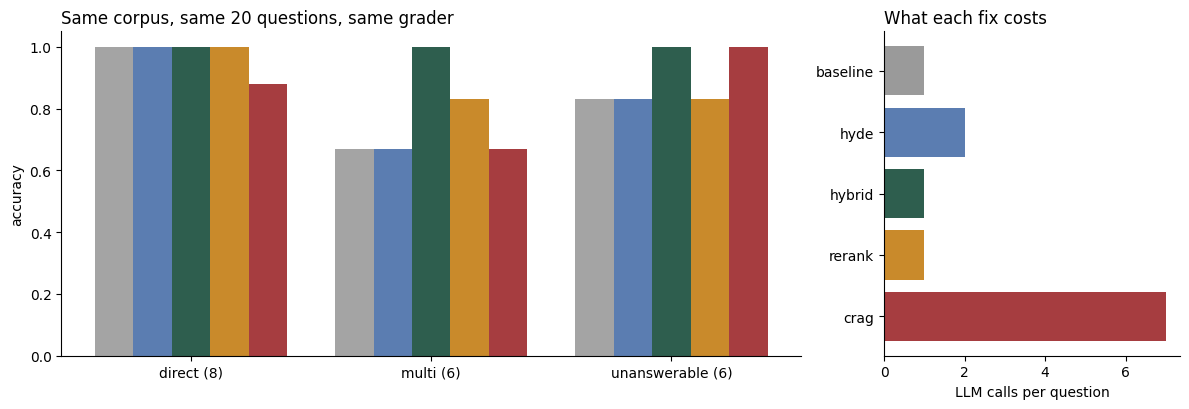

⏱ 0.5 s


In [45]:
ALL = [df_base, df_hyde, df_hybrid, df_rerank, df_crag]
summary = summarize(ALL)
pd.concat(ALL, ignore_index=True).to_csv("results_lesson09.csv", index=False)
display(summary)
plot_comparison(summary)                                       # grava lesson09_scoreboard.png para os slides